<a href="https://colab.research.google.com/github/zk025815-beep/HCCDA-AI-Course/blob/main/Cats_and_Dogs_Image_Classification_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub

import kagglehub
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("samuelcortinhas/cats-and-dogs-image-classification")

print("Dataset downloaded to:", path)
print("Contents:", os.listdir(path))

100%|██████████| 64.4M/64.4M [00:00<00:00, 136MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/samuelcortinhas/cats-and-dogs-image-classification/versions/4
Contents: ['test', 'train']


In [2]:
!pip install -q kagglehub

import kagglehub
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("samuelcortinhas/cats-and-dogs-image-classification")

print("Dataset downloaded to:", path)
print("Contents:", os.listdir(path))

Using Colab cache for faster access to the 'cats-and-dogs-image-classification' dataset.
Dataset downloaded to: /kaggle/input/cats-and-dogs-image-classification
Contents: ['test', 'train']


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 1. Training split (80% of train folder)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# 2. Validation split (20% of train folder)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# 3. Test dataset for final evaluation
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Save class names from the raw dataset before wrapping it with cache/prefetch
class_names = train_ds.class_names
print("Class Names:", class_names)  # ['cats', 'dogs']

# Optimize memory pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Found 140 files belonging to 2 classes.
Class Names: ['cats', 'dogs']


In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

# 2. CNN Architecture with Batch Normalization
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train for 12 epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,953 (16.07 MB)

 Trainable params: 4,213,889 (16.07 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.4574 - loss: 5.2930 - val_accuracy: 0.5135 - val_loss: 0.7011
Epoch 2/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5179 - loss: 0.9449 - val_accuracy: 0.5135 - val_loss: 0.6901
Epoch 3/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5561 - loss: 0.6766 - val_accuracy: 0.5135 - val_loss: 0.6895
Epoch 4/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5650 - loss: 0.6711 - val_accuracy: 0.5135 - val_loss: 0.6882
Epoch 5/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6076 - loss: 0.6602 - val_accuracy: 0.5135 - val_loss: 0.6875
Epoch 6/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6166 - loss: 0.6537 - val_accuracy: 0.5225 - val_loss: 0.6864
Epoch 7/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6031 - loss: 0.6541 - val_accuracy: 0.5315 - val_loss: 0.6839
Epoch 8/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5695 - loss: 0.6663 - val_accuracy: 0.5586 - 

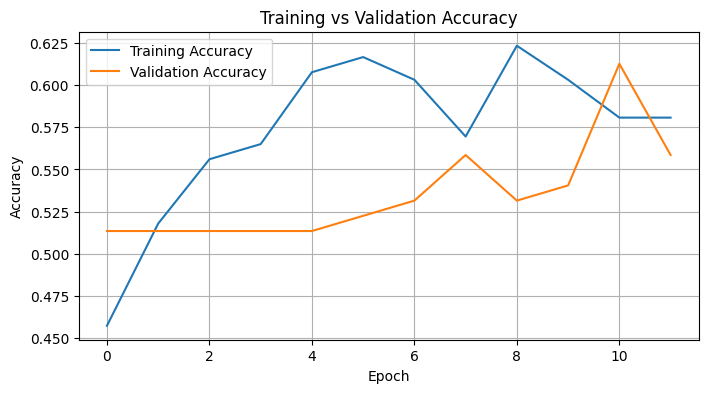

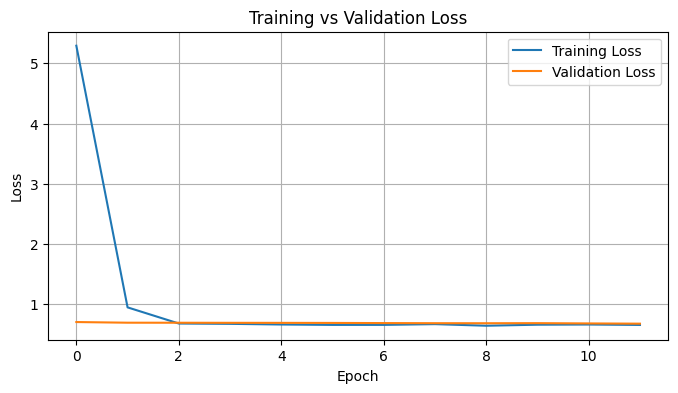

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5286 - loss: 0.6963

Final Test Loss: 0.6963
Final Test Accuracy: 52.86%
Saved as cats_dogs_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# 1. Training & Validation Accuracy Graph
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 2. Training & Validation Loss Graph
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 3. Test Evaluation
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

# # 4. Save and Download Model
# model.save("cats_dogs_model.keras")
# print("Saved as cats_dogs_model.keras")

# from google.colab import files
# files.download("cats_dogs_model.keras")